ΚΟΥΜΠΟΓΙΑΝΝΗ ΧΡΙΣΤΙΝΑ, Α.Μ. 01735

# ΕΙΣΑΓΩΓΗ
Η ιστοπαθολογία αναφέρεται στην εξέταση δειγμάτων ιστού κάτω από ένα μικροσκόπιο για τη μελέτη των αλλαγών ή ανωμαλιών στις κυτταρικές δομές. Στο πλαίσιο του καρκίνου, η ιστοπαθολογία παίζει καθοριστικό ρόλο στη διάγνωση και τον χαρακτηρισμό των όγκων αναλύοντας την κυτταρική σύνθεση και αρχιτεκτονική.
Το **"Lung and Colon Cancer Histopathological Image Dataset"** είναι ένα σύνολο δεδομένων που αποτελείται από 25.000 ιστοπαθολογικές εικόνες. Οι εικόνες κατηγοριοποιούνται σε πέντε κατηγορίες, με κάθε κατηγορία να περιέχει 5.000 εικόνες. Το σύνολο δεδομένων περιλαμβάνει εικόνες που αντιπροσωπεύουν τόσο υγιή ιστό όσο και καρκινικό ιστό από δύο τύπους καρκίνου του πνεύμονα και έναν τύπο καρκίνου του εντέρου. Ο στόχος αυτού του συνόλου δεδομένων είναι να αναπτύξει ένα μοντέλο ταξινόμησης που μπορεί να ταξινομήσει με ακρίβεια τις ιστοπαθολογικές εικόνες στις αντίστοιχες κατηγορίες τους. Με την ανάλυση των εικόνων, ο στόχος είναι να γίνει διάκριση μεταξύ υγιούς ιστού και διαφορετικών τύπων καρκινικού ιστού τόσο σε δείγματα πνεύμονα όσο και σε δείγματα εντέρου.

#### ΦΟΡΤΩΣΗ ΤΩΝ ΑΠΑΡΑΙΤΗΤΩΝ ΒΙΒΛΙΟΘΗΚΩΝ
Στο παρακάτω κελί πραγματοποιείται εισαγωγή διαφόρων βιβλιοθηκών και ενοτήτων που σχετίζονται με τη μηχανική μάθηση και τη βαθιά μάθηση.

In [2]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from sklearn.preprocessing import LabelEncoder

import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pathlib
import seaborn as sns


# ΦΟΡΤΩΣΗ ΤΟΥ ΣΥΝΟΛΟΥ ΔΕΔΟΜΕΝΩΝ (DATA LOADING)


In [3]:
#find the path of each dataset
folder1_path = 'C:\\Users\\Χριστινα\\Desktop\\Deep Learning\\lung_colon_image_set\\lung_image_sets' 
folder2_path = 'C:\\Users\\Χριστινα\\Desktop\\Deep Learning\\lung_colon_image_set\\colon_image_sets'

# Create an instance of ImageDataGenerator
datagen = ImageDataGenerator(rescale=1.0/255.0, validation_split=0.2) #performs the rescaling during the data generation process, 
image_width = 64 #set the image size
image_height = 64
labels = list()  #Initializing an empty list

# Load the dataset from the first folder(lung_image_sets)
class_names = sorted(os.listdir(folder1_path))  #get the list of all files in the specified directory
num_classes = len(class_names)

print("Class Names:", class_names)
print("Number of Classes:", num_classes)
print('')

lungImages = [] #Initializing empty list
lungLabels = []

for class_name in class_names:
    folder_path = os.path.join(folder1_path, class_name) #join the directory path and the file name together to create the full path of each file
    num_images1 = len(os.listdir(folder_path))
    print(f"Folder: {class_name} - Number of Images: {num_images1}")
    print('-------------------------------------------------------')

    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        pil_img = image.load_img(path=img_path, color_mode="rgb", target_size=(image_width, image_height))
        lungImages.append(image.img_to_array(pil_img)) #covert and appent each image to NumPy array
        lungLabels.append(class_name)

lungImages = np.array(lungImages) #covert to NumPy arrays
lungLabels = np.array(lungLabels)

# Load the dataset from the second folder (colon_image_sets)
class_names = sorted(os.listdir(folder2_path))
num_classes = len(class_names)

print("Class Names:", class_names)
print("Number of Classes:", num_classes)
print('')

colonImages = [] #initializing empty lists
colonLabels = []

for class_name in class_names:
    folder_path = os.path.join(folder2_path, class_name)
    num_images2 = len(os.listdir(folder_path))
    print(f"Folder: {class_name} - Number of Images: {num_images2}")
    print('-------------------------------------------------------')

    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        pil_img = image.load_img(path=img_path, color_mode="rgb", target_size=(image_width, image_height))
        colonImages.append(image.img_to_array(pil_img))
        colonLabels.append(class_name)

colonImages = np.array(colonImages)
colonLabels = np.array(colonLabels)


Class Names: ['lung_aca', 'lung_n', 'lung_scc']
Number of Classes: 3

Folder: lung_aca - Number of Images: 5000
-------------------------------------------------------
Folder: lung_n - Number of Images: 5000
-------------------------------------------------------
Folder: lung_scc - Number of Images: 5000
-------------------------------------------------------
Class Names: ['colon_aca', 'colon_n']
Number of Classes: 2

Folder: colon_aca - Number of Images: 5000
-------------------------------------------------------
Folder: colon_n - Number of Images: 5000
-------------------------------------------------------


Το αποτέλεσμα δείχνει ότι υπάρχουν ξεχωριστά σύνολα δεδομένων: Τα lungImages και colonImages, που περιέχουν τις εικόνες από τα σύνολα δεδομένων πνευμόνων και εντέρου, αντίστοιχα. Οι αντίστοιχες ετικέτες αποθηκεύονται στα lungLabels και colonLabels.

Έπειτα, συνενώνω τα lung και colon datasets στον πρώτο άξονα των πινάκων images και labels. 


In [4]:
#Combine the lung and colon datasets in one dataset
images = np.concatenate((lungImages, colonImages), axis=0) #along the first axis
labels = np.concatenate((lungLabels, colonLabels), axis=0)

print(images.shape)
print(labels.shape)


(25000, 64, 64, 3)
(25000,)


- Στο output, παρατηρώ  ο πίνακας images είναι τεσσάρων διαστάσεων: Το 25000 αντιπροσωπεύει το σύνολο των εικόνων, τα (64,64) το πλάτος και το μήκος των εικόνων, και το 3 το πλήθος των καναλιών χρώματος (RGB).
- O πίνακας images είναι μονοδιάστατος και το 25000 αντιστοιχεί στο πλήθος των labels για όλες τις εικόνες συνολικά. Κάθε ετικέτα αντιστοιχεί σε μία εικόνα.

Στο κελί που ακολουθεί πραγματοποιείται η εύερεση των μοναδικών ετικετών που αντιστοιχούν στις κλάσεις.

In [5]:
classes = np.unique(labels) 
classes

array(['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc'],
      dtype='<U9')

Δημιουργείται ένα λεξικό label_dict όπου οι ετικέτες από το πίνακα classes αντιστοιχούνται σε μία ακέραια τιμή

In [6]:
# Define label dictionary
label_dict = {label: i for i, label in enumerate(classes)}
label_dict

{'colon_aca': 0, 'colon_n': 1, 'lung_aca': 2, 'lung_n': 3, 'lung_scc': 4}

Το ακόλουθο κελί πραγματοποιεί αντιστοίχιση των ονομάτων των κλάσεων σε ακέραιους αριθμούς και στη συνέχεια πραγματοπποιεί **one-hot encoding** σε όλους τους ακεραίους. Αυτό γίνεται με τη χρήση της συνάρτησης *to_categorical* που μετατρέπει τις ακέραιες ετικέτες σε one-hot κωδικοποιημένα διανύσματα.

In [7]:
# Map the class names to integers using the label_dict dictionary
labels_int = np.array([label_dict[label] for label in labels.flatten()])

# Convert the integer labels to one-hot encoded vectors
labels_categorical = to_categorical(labels_int, num_classes=len(label_dict)).astype(int)

Εδώ διαχωρίζονται τα δεδομένα σε *train set* και *test set*, τόσο για τις εικόνες όσο και για τις ετικέτες. Η παράμετρος test_size έχει οριστεί σε 0,2, υποδεικνύοντας ότι το 20% των δεδομένων θα χρησιμοποιηθεί για δοκιμές (testing), ενώ το υπόλοιπο 80% θα χρησιμοποιηθεί για εκπαίδευση (training).

In [8]:
# Split data into train and test sets
train_images, test_images, train_labels, test_labels = train_test_split(images, labels_categorical, test_size=0.2, random_state=42)

Εμφάνιση του συνόλου των κλάσεων που χρησιμοποιήθηκαν στο training dataset και στο test dataset

In [9]:
# Compute the number of classes
num_train_classes = len(np.unique(labels))
num_test_classes = len(np.unique(labels))

print("Number of Classes in Training Dataset:", num_train_classes)
print("Number of Classes in Validation Dataset:", num_test_classes)

Number of Classes in Training Dataset: 5
Number of Classes in Validation Dataset: 5


Αυτό το βήμα κανονικοποίησης κλιμακώνει τις τιμές των εικονοστοιχείων από το εύρος [0, 255] σε [0, 1]

In [10]:
#Normalization
train_images = train_images / 255
test_images = test_images / 255

Αυτές οι γραμμές υπολογίζουν και εκτυπώνουν τις ελάχιστες και μέγιστες τιμές pixel του συνόλου εκπαίδευσης και δοκιμής, ώστε να γίνει έλεγχος εάν η κανονικοποίηση έγινε σωστά.

In [11]:
# Print the minimum and maximum pixel values of the training set
print("Minimum Pixel Value (Training Set):", np.min(train_images))
print("Maximum Pixel Value (Training Set):", np.max(train_images))
print('')

# Print the minimum and maximum pixel values of the test set
print("Minimum Pixel Value (Test Set):", np.min(test_images))
print("Maximum Pixel Value (Test Set):", np.max(test_images))

Minimum Pixel Value (Training Set): 0.0
Maximum Pixel Value (Training Set): 1.0

Minimum Pixel Value (Test Set): 0.0
Maximum Pixel Value (Test Set): 1.0


Πραγματοποιείται οπτικοποίηση κάποιων εικόνων του συνόλου δεδομένων εκπαίδευσης. 

Random Index Samples: [15795   860  5390 11964 11284  6265 16850  4426 14423]


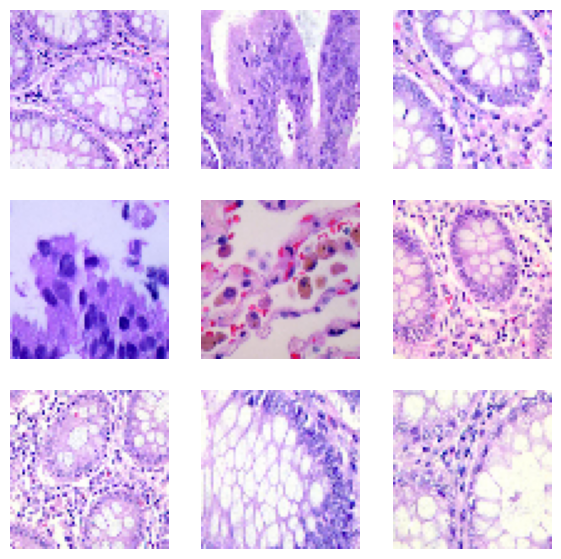

In [12]:
#Display a set of images from the training dataset
np.random.seed(42) #for the same random samples

# Obtain a number of random samples from the training dataset
# by randomly sampling the indices of these images

number_of_samples = 9 #define the number of samples
random_samples = np.random.randint(0, # the closed lower boundary of random integers
                                   train_images.shape[0], # the open upper boundary of random integers
                                   size=(number_of_samples,) #number of samples
                                  )
print("Random Index Samples:", random_samples)

#These lines extract the randomly selected images and their labels 
#based on the randomly generated indices.
random_train_images = train_images[random_samples]
random_label_images = train_labels[random_samples]

# create a subplot grid
fig, ax = plt.subplots(nrows = 3, ncols=3, figsize=(7, 7))
cntr=0
for i in range(3):
    for j in range(3):
        ax[i,j].imshow(random_train_images[cntr])  #displayed image RGB
        ax[i,j].axis("off")
        cntr += 1
plt.show()

# ΔΗΜΙΟΥΡΓΙΑ ΤΟΥ ΜΟΝΤΕΛΟΥ

Αυτό το τμήμα κώδικα δημιουργεί ένα μοντέλο συνελικτικού νευρωνικού δικτύου (CNN) χρησιμοποιώντας τη βιβλιοθήκη Keras.Η επιθυμητή αρχιτεκτονική, θα αποτελείται από μια στοίβα επιπέδων τα οποία θα συνδέονται ακολουθιακά, και έτσι η υλοποίηση της μπορεί να πραγματοποιηθεί μέσω της κατασκευής ενός Ακολουθιακού Μοντέλου (Sequential Model). Επίσης, χρησιμοποιείται η μέθοδος summary του μοντέλου, που δημιουργήθηκε για να απεικονιστεί σχηματικά η αρχιτεκτονική του κατασκευασμένου δικτύου.
Αναλυτικότερα:
1. **Input Shape**: Δέχεται εικόνες εισόδου μεγέθους 64x64 pixel με 3 έγχρωμα κανάλια (RGB)
2. **Convolution Layers**: 
    - Το **πρώτο** επίπεδο Conv2D έχει 32 φίλτρα (δηλαδή θα εξαχθεί χάρτης εξόδου 32 χαρακτηριστικών), μέγεθος πυρήνα/παράθυρο ολίσθησης (3,3), εφαρμόζει "ίδιο" padding και χρησιμοποιεί τη συνάρτηση ενεργοποίησης ReLU.
    -  Το **δεύτερο** επίπεδο Conv2D έχει 64 φίλτρα, μέγεθος πυρήνα (3,3) και εφαρμόζει "ίδιο" padding. Χρησιμοποιεί επίσης τη συνάρτηση ενεργοποίησης ReLU.
    -  Το **τρίτο** επίπεδο Conv2D έχει 128 φίλτρα, μέγεθος πυρήνα (3,3) και εφαρμόζει "ίδιο" padding. Χρησιμοποιεί τη συνάρτηση ενεργοποίησης ReLU.
3. **Max Pooling Layers**: Μετά από κάθε επίπεδο Conv2D, εφαρμόζεται ένα στρώμα MaxPooling2D (3 συνολικά) με pool_size (2,2). Έτσι, επιτυγχάνεται η υποδειγματοληψία, μειώνει την διάσταση των χωρικών διαστάσεων λαμβάνοντας την μέγιστη τιμή σε κάθε μπλοκ 2x2 του χάρτη χαρακτηριστικών εισόδου.Δύο ακόμη επίπεδα Conv2D και MaxPooling2D προστίθενται με αυξανόμενο αριθμό φίλτρων.
4. **Dropout Layers**: Δύο στρώματα Dropout προστίθενται, ένα μετά το τρίτο στρώμα MaxPooling2D και ένα μετά το επίπεδο Flatten, αντίστοιχα. Το dropout rate=0,5, πράγμα που σημαίνει ότι κατά τη διάρκεια της εκπαίδευσης, το 50% των μονάδων στα αντίστοιχα επίπεδα ορίζεται τυχαία στο 0 σε κάθε ενημέρωση για να αποφευχθεί το overfitting.
5. **Flatten Layer**: Μετατρέπει την έξοδο του προηγούμενου επιπέδου/στρώματος σε διάνυσμα. Μετατρέπει χάρτες χαρακτηριστικών 8x8x128 σε επίπεδο διάνυσμα μήκους 8192.
6. **Dense Layers**: 
    - Το **πρώτο** Dense layer έχει 256 νευρώνες και χρησιμοποιεί τη συνάρτηση ενεργοποίησης ReLU. Λειτουργεί ως μετασχηματισμός των χαρακτηριστικών εισόδου σε έναν χώρο μειωμένων διαστάσεων ως ενδιάμεση αναπαράσταση και καταγράφει χαρακτηριστικά υψηλότερου επιπέδου.
    - Το **δεύτερο** Dense layer έχει 5 νευρώνες, που αντιστοιχούν στις 5 κλάσεις ταξινόμησης. Χρησιμοποιεί τη συνάρτηση ενεργοποίησης softmax για να παράγει την τελική κατανομή πιθανοτήτων στις 5 κλάσεις.

In [13]:
import keras

# Κατασκευή Ακολουθιακού Μοντέλου
cnn_model = keras.models.Sequential([keras.layers.Conv2D(filters=32, # πλήθος συνελικτικών φίλτρων
                                                        kernel_size=(3,3), # μέγεθος συνελικτικών φίλτρων
                                                        padding="same", # είδος padding -  same -> διαστάσεις εικόνων εξόδου = διαστάσεις εικόνων εισόδου
                                                        activation="relu", #define activation function
                                                        input_shape=(64,64,3)), #define input shape
                                     keras.layers.MaxPooling2D(pool_size=(2,2) #  Εφάρμοσε Max-Pooling με υποδιπλασιασμό κάθε διάστασης
                                                              ),
                                     keras.layers.Conv2D(filters=64,
                                                        kernel_size=(3,3),
                                                        padding="same",
                                                        activation="relu"),
                                     keras.layers.MaxPooling2D(pool_size=(2,2)),
                                     keras.layers.Conv2D(filters=128,
                                                        kernel_size=(3,3),
                                                        padding="same",
                                                        activation="relu"),
                                     keras.layers.MaxPooling2D(pool_size=(2,2)),
                                     keras.layers.Dropout(rate=0.5),
                                     keras.layers.Flatten(), # Κάνε την έξοδο του προηγούμενου επιπέδου διάνυσμα
                                     keras.layers.Dropout(rate=0.5),
                                     keras.layers.Dense(units=256, 
                                                        activation="relu"
                                                       ),
                                     # επίπεδο εξόδου
                                     keras.layers.Dense(units=5, # 5 νευρώνες επειδή έχω 5 κλάσεις
                                                        activation="softmax" # Συνάρτηση ενεργοποίησης για Ταξινόμηση πολλών κλάσεων
                                                       )
                                    ]
                                   ) 
cnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 64, 64, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 32, 32, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 16, 16, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 8, 8, 128)        0

Στην συνέχεια, προστίθενται στο μοντέλο, οι πληροφορίες αναφορικά με τον αλγόριθμο προσαρμογής (fitting algorithm). Συγκεκριμένα, θα ελαχιστοποιηθεί η συνάρτηση σφάλματος Cross-Entropy (Cross-Entropy Loss Function), ενώ ο Βελτιστοποιητής (Optimizer), που θα χρησιμοποιηθεί είναι ο "adam". Παράλληλα, κατά την διάρκεια της εκπαίδευσης και της επαλήθευσης θα υπολογίζεται και η μετρική της Ακρίβειας (Accuracy).

In [14]:
# Compile the model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Στο σημείο αυτό, είναι εφικτή η έναρξη της εκπαίδευσης του Συνελικτικού Νευρωνικού Δίκτου, που κατασκευάστηκε. Η διαδικασία αυτή, πραγματοποιείται μέσω της μεθόδου fit, που διαθέτει το μοντέλο που δημιουργήθηκε. Ειδικότερα, στις δύο πρώτες παραμέτρους, θα τοποθετηθούν τα δεδομένα εκπαίδευσης (train images, train labels). Επίσης, ορίστηκε το μέγεθος της ομάδας παρατηρήσεων (batch size = 32) ανα βήμα της Στοχαστικής Κατάβασης Παραγώγου και το πλήθος των εποχών = 10: Αυτό καθορίζει πόσες φορές θα επαναληφθεί το μοντέλο σε ολόκληρο το σύνολο δεδομένων εκπαίδευσης. Ακόμα, παρέχεται σύνολο δεδομένων επαλήθευσης μέσω της παραμέτρου validation_data που περιέχει το test_images: είναι οι εικόνες εισόδου για επικύρωση και το test_labels: είναι οι αντίστοιχες ετικέτες. Το μοντέλο θα αξιολογήσει την απόδοσή του στα δεδομένα επικύρωσης μετά από κάθε εποχή.

In [ ]:
#annealer = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, verbose=1, min_lr=1e-3)
#checkpoint = ModelCheckpoint('best_model.h5', verbose=1, save_best_only=True)

In [23]:
# Train the model
history = cnn_model.fit(train_images, train_labels, epochs = 10, validation_data = (test_images, test_labels),batch_size=32)

Epoch 1/10
625/625 [==============================] - 111s 177ms/step - loss: 0.0229 - accuracy: 0.9930 - val_loss: 0.0454 - val_accuracy: 0.9842
Epoch 2/10
625/625 [==============================] - 106s 170ms/step - loss: 0.0272 - accuracy: 0.9912 - val_loss: 0.0499 - val_accuracy: 0.9864
Epoch 3/10
625/625 [==============================] - 102s 163ms/step - loss: 0.0268 - accuracy: 0.9916 - val_loss: 0.0411 - val_accuracy: 0.9888
Epoch 4/10
625/625 [==============================] - 101s 161ms/step - loss: 0.0227 - accuracy: 0.9924 - val_loss: 0.0247 - val_accuracy: 0.9930
Epoch 5/10
625/625 [==============================] - 102s 164ms/step - loss: 0.0327 - accuracy: 0.9900 - val_loss: 0.0368 - val_accuracy: 0.9860
Epoch 6/10
625/625 [==============================] - 103s 165ms/step - loss: 0.0215 - accuracy: 0.9926 - val_loss: 0.0494 - val_accuracy: 0.9818
Epoch 7/10
625/625 [==============================] - 113s 181ms/step - loss: 0.0183 - accuracy: 0.9934 - val_loss: 0.0426 -

Η εκπαιδευτική διαδικασία αποτελείται από 10 εποχές, με κάθε εποχή να επαναλαμβάνεται πάνω από το dataset σε τμήματα.
     Για κάθε εποχή, εμφανίζονται η ακρίβεια εκπαίδευσης, η απώλεια εκπαίδευσης, η ακρίβεια επικύρωσης, η απώλεια επικύρωσης και ο ρυθμός εκμάθησης.
     Στο τέλος κάθε εποχής, αξιολογείται η απόδοση του μοντέλου στο σύνολο επικύρωσης και εάν η απώλεια επικύρωσης βελτιωθεί σε σύγκριση με την προηγούμενη καλύτερη απώλεια.
     Η διαδικασία εκπαίδευσης χρησιμοποιεί ένα batch_size = 32, υποδεικνύοντας ότι το σύνολο δεδομένων χωρίζεται σε τμήματα των 32 δειγμάτων για κάθε βήμα εκπαίδευσης.
     Η διαδικασία εκπαίδευσης περιλαμβάνει βήματα όπως ο υπολογισμός της απώλειας, ο υπολογισμός των κλίσεων και η ενημέρωση των βαρών του μοντέλου χρησιμοποιώντας το βελτιστοποιητή Adam.
     Η μέτρηση ακρίβειας χρησιμοποιείται για τη μέτρηση της απόδοσης του μοντέλου κατά την εκπαίδευση και την επικύρωση.

Το ακόλουθο τμήμα κώδικα χρησιμοποιείται για τον υπολογισμό και την εκτύπωση της **ακρίβειας** του μοντέλου νευρωνικού δικτύου (cnn_model) στα δεδομένα δοκιμής (test data).

In [24]:
# Load the libraries
import sklearn.metrics
import numpy as np

# make the prediction
predictions_nn_probs = cnn_model.predict(test_images)

#assigned each image to the class with the highest probability
predictions_nn = np.argmax(predictions_nn_probs, axis=1)

#Calculate the accuracy 
test_labels_multiclass = np.argmax(test_labels, axis=1)
test_accuracy_nn = sklearn.metrics.accuracy_score(test_labels_multiclass, predictions_nn)

print("The Accuracy of the Neural Network on the Test Data is", test_accuracy_nn)


157/157 [==============================] - 6s 35ms/step
The Accuracy of the Neural Network on the Test Data is 0.9888


Η τιμή της Ακρίβειας (Accuracy), σημαίνει ότι το νευρωνικό δίκτυο πρόβλεψε σωστά το 98%.

In [27]:
# Evaluate the model
loss, accuracy = cnn_model.evaluate(test_images, test_labels)
print('Test accuracy:', accuracy)

157/157 [==============================] - 5s 32ms/step - loss: 0.0362 - accuracy: 0.9888
Test accuracy: 0.9887999892234802


Οπτικοποιώντας τις καμπύλες ακρίβειας, παρατηρoύμε πώς η ακρίβεια του μοντέλου αλλάζει κατά τη διάρκεια των εποχών εκπαίδευσης τόσο για τα σύνολα δεδομένων εκπαίδευση (train set) όσο και για την επικύρωση (validation). Στο ακόλουθο τμήμα κώδικα δημιουργείται ένα figure με δύο subplots δίπλα-δίπλα. Το αριστερό subplot δείχνει τις τιμές απώλειας τόσο για τα σετ εκπαίδευσης όσο και για τα σύνολα επικύρωσης, ενώ το δεξί υπογραφικό εμφανίζει τις τιμές ακρίβειας.

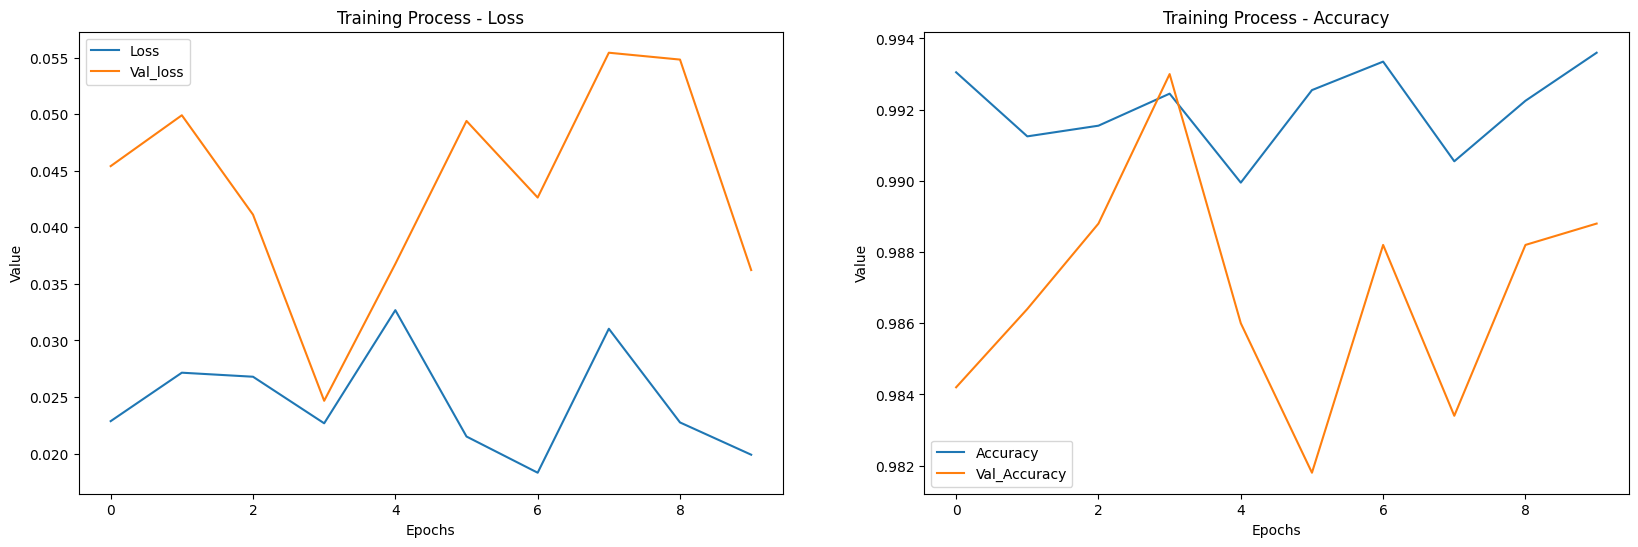

In [25]:
#Create a graph that will have 2 subgraphs next to each other
fig, axis = plt.subplots(nrows=1,ncols=2, figsize=(20,6))

#Creating the first chart (left)
axis[0].plot(history.epoch, history.history['loss']) #create Cross Entropy plot of training
axis[0].plot(history.epoch, history.history['val_loss']) #create Cross Entropy plot of validation
axis[0].set_xlabel("Epochs") #horizontal axis title definition 
axis[0].set_ylabel("Value") #vertical axis title definition
axis[0].legend(["Loss", "Val_loss"]) 
axis[0].set_title("Training Process - Loss") #chart title definition

#Creating the second graph (right) - Same process but for Accuracy
axis[1].plot(history.epoch, history.history['accuracy'])
axis[1].plot(history.epoch, history.history['val_accuracy'])
axis[1].set_xlabel("Epochs") 
axis[1].set_ylabel("Value") 
axis[1].legend(["Accuracy", "Val_Accuracy"])
axis[1].set_title("Training Process - Accuracy")
plt.show()

**Left Sublpot**: το γράφημα οπτικοποιεί την προόδο της προπόνησης δείχνοντας πώς αλλάζουν οι τιμές απώλειας κατά τη διάρκεια της προπόνησης. 
- Το train loss (μπλε γραμμή) μειώνεται σταθερά όσο αυξάνεται ο αριθμός των εποχών. Αυτό δείχνει ότι το μοντέλο μαθαίνει και βελτιώνει την απόδοσή του στα δεδομένα εκπαίδευσης.

- Η απώλεια επικύρωσης (val loss) επίσης μειώνεται αρχικά και φτάνει σε σχετικά σταθερό επίπεδο μετά από μερικές εποχές. Αυτό υποδηλώνει ότι το μοντέλο γενικεύεται καλά σε μη ορατά δεδομένα.  Το γεγονός ότι η απώλεια επικύρωσης είναι χαμηλότερη από την απώλεια εκπαίδευσης υποδηλώνει ότι το μοντέλο δεν ταιριάζει υπερβολικά και είναι σε θέση να αποδώσει καλά σε νέα παραδείγματα.

- Η απώλεια εκπαίδευσης και η απώλεια επικύρωσης εμφανίζουν πτωτική τάση, υποδεικνύοντας ότι το μοντέλο μαθαίνει και σημειώνει πρόοδο.

- H απώλεια επικύρωσης αρχίζει να αυξάνεται ελαφρώς μετά από έναν ορισμένο αριθμό εποχών. Αυτό θα μπορούσε να υποδηλώνει ότι το μοντέλο μπορεί να έχει αρχίσει να προσαρμόζεται υπερβολικά στα δεδομένα εκπαίδευσης

**Right Subplot**: Το γράφημα δείχνει τις αλλαγές στην ακρίβεια κατά τις εποχές εκπαίδευσης τόσο για τα σύνολα δεδομένων εκπαίδευσης όσο και για την επικύρωση. Ακολουθεί μια ερμηνεία του γραφήματος με βάση τις παρεχόμενες πληροφορίες:

- Αρχικά, στην Εποχή 1, η ακρίβεια εκπαίδευσης ξεκινά από περίπου 0,77, υποδεικνύοντας ότι το μοντέλο ταξινόμησε σωστά περίπου το 77% των δειγμάτων εκπαίδευσης.
- Η ακρίβεια επικύρωσης στην Εποχή 1 είναι περίπου 0,89, πράγμα που σημαίνει ότι το μοντέλο πέτυχε ακρίβεια 89% στο σύνολο επικύρωσης. Αυτό δείχνει ότι το μοντέλο αποδίδει καλύτερα στο σετ επικύρωσης σε σύγκριση με το σετ εκπαίδευσης.
- Καθώς προχωρά η εκπαίδευση, η ακρίβεια του μοντέλου βελτιώνεται. Στην Εποχή 5, η ακρίβεια εκπαίδευσης φτάνει περίπου το 0,94, υποδεικνύοντας ότι το μοντέλο ταξινομεί σωστά περίπου το 94% των δειγμάτων εκπαίδευσης.
- Η ακρίβεια επικύρωσης βελτιώνεται επίσης με την πάροδο του χρόνου. Στην Εποχή 5, η ακρίβεια επικύρωσης αυξάνεται σε περίπου 0,96, δείχνοντας ότι το μοντέλο επιτυγχάνει ακρίβεια 96% στο σύνολο επικύρωσης.
- Είναι σημαντικό να σημειωθεί ότι μετά την Εποχή 5, η ακρίβεια εκπαίδευσης συνεχίζει να βελτιώνεται, φτάνοντας περίπου το 0,98 στην Εποχή 20. Παράλληλα, η ακρίβεια επικύρωσης αυξάνεται σε περίπου 0,98 στην Εποχή 20.
- H ακρίβεια επικύρωσης φαίνεται να αυξάνεται ή να μειώνεται ελαφρώς μετά από έναν ορισμένο αριθμό εποχών. Αυτή η συμπεριφορά θα μπορούσε επίσης να υποδεικνύει την πιθανή υπερπροσαρμογή του μοντέλου στα δεδομένα εκπαίδευσης.

Το γράφημα δείχνει ότι το μοντέλο βελτιώνεται στην ακρίβεια τόσο στα σύνολα εκπαίδευσης όσο και στα σύνολα επικύρωσης.

Το ακόλουθο τμήμα κώδικα υπολογίζει και απεικονίζει έναν πίνακα σύγχυσης με βάση τις αληθινές ετικέτες και τις προβλεπόμενες ετικέτες ενός μοντέλου ταξινόμησης. 
Η συνάρτηση `confusion_matrix` χρησιμοποιείται για τον υπολογισμό του πίνακα σύγχυσης από τις αληθινές ετικέτες και τις προβλεπόμενες ετικέτες. Επιστρέφει έναν πίνακα που περιέχει τις μετρήσεις των αληθινών θετικών (ΤΡ), των αληθινών αρνητικών (ΤΝ), των ψευδώς θετικών (FP) και των ψευδών αρνητικών (FN).
Ακόμη, δημιουργείται μια απεικόνιση θερμικού χάρτη της μήτρας σύγχυσης χρησιμοποιώντας το `sns.heatmap`.

157/157 [==============================] - 5s 31ms/step
The confusion matrix of the classification is:
Predicted  colon_aca  colon_n  lung_aca  lung_n  lung_scc   All
Actual                                                         
colon_aca        976       13         0       0         0   989
colon_n            1     1004         0       0         0  1005
lung_aca           3        0       999       4        15  1021
lung_n             0        0         0    1000         0  1000
lung_scc           0        0        20       0       965   985
All              980     1017      1019    1004       980  5000
----------------------------------------------------------------------------------------------------


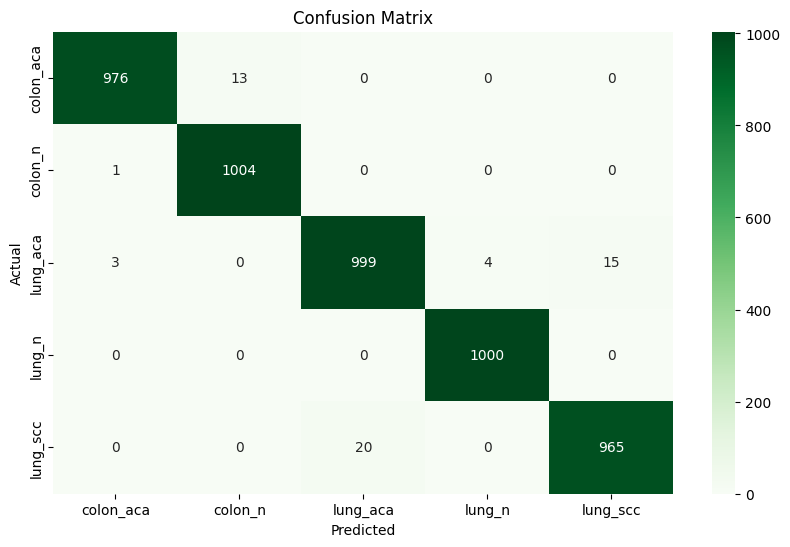

In [30]:
import sklearn.metrics

# Make the prediction
predictions_nn_probs = cnn_model.predict(test_images)

# Assign each image to the class with the highest probability
predictions_nn = np.argmax(predictions_nn_probs, axis=1)

# Calculate the confusion matrix
cm = sklearn.metrics.confusion_matrix(np.argmax(test_labels, axis=1), predictions_nn)

# Get class names from label dictionary
class_names = list(label_dict.keys())

# Create a DataFrame for the confusion matrix
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# Add row and column names for clarity
cm_df.index.name = 'Actual'
cm_df.columns.name = 'Predicted'

# Add row and column for totals
cm_df['All'] = cm_df.sum(axis=1)
cm_df.loc['All'] = cm_df.sum(axis=0)

# Print the confusion matrix
print("The confusion matrix of the classification is:")
print(cm_df)
print("-" * 100)

# Plot the confusion matrix heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cm_df.iloc[:-1, :-1], annot=True, cmap='Greens', fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Ο παρεχόμενος πίνακας σύγχυσης αντιπροσωπεύει τα αποτελέσματα ταξινόμησης για ένα πρόβλημα ταξινόμησης πολλαπλών κλάσεων με πέντε κατηγορίες καρκίνου: colon_aca, colon_n, lung_aca, lung_n και lung_scc.

- Οι σειρές του πίνακα αντιπροσωπεύουν τις πραγματικές (αληθινές) ετικέτες.
- Οι στήλες του πίνακα αντιπροσωπεύουν τις προβλεπόμενες ετικέτες.
- Οι τιμές εντός του πίνακα αντιπροσωπεύουν τον αριθμό των δειγμάτων.

1. Προβλεπόμενες τάξεις:
    - Οι προβλεπόμενες κατηγορίες παρατίθενται ως κεφαλίδες στηλών: colon_aca, colon_n, lung_aca, lung_n και lung_scc.
    - Αυτές οι κατηγορίες αντιπροσωπεύουν τους τύπους καρκίνου που προβλέπονται από το μοντέλο.

2. Πραγματικές τάξεις:
    - Οι πραγματικές κατηγορίες παρατίθενται ως δείκτες σειρών: colon_aca, colon_n, lung_aca, lung_n και lung_scc.
    - Αυτές οι κατηγορίες αντιπροσωπεύουν τους πραγματικούς τύπους καρκίνου που υπάρχουν στο σύνολο δεδομένων.

3. Τιμές κελιών:
    - Οι τιμές εντός του πίνακα υποδεικνύουν τον αριθμό των δειγμάτων που προβλεπόταν ότι ανήκουν σε μια συγκεκριμένη κλάση (στήλη) και στην πραγματικότητα ανήκουν σε μια συγκεκριμένη κατηγορία.
    - Για παράδειγμα, το κελί στη γραμμή "colon_aca" και στη στήλη "colon_aca" έχει τιμή 976, που σημαίνει ότι 976 παρουσίες της κλάσης "colon_aca" είχαν προβλεφθεί σωστά ως "colon_aca".
    - Στη σειρά "colon_aca", από τις 989 περιπτώσεις της κλάσης "colon_aca", οι 976 είχαν προβλεφθεί σωστά ως "colon_aca" και υπήρχαν 13 περιπτώσεις όπου το "colon_aca" είχε προβλεφθεί λανθασμένα ως κάτι άλλο.

Ο πίνακας σύγχυσης αποκαλύπτει την απόδοση του μοντέλου στην ταξινόμηση των δειγμάτων στις αντίστοιχες κατηγορίες τους.
Στην περίπτωση αυτή, τα περισσότερα δείγματα ταξινομήθηκαν σωστά, καθώς τα διαγώνια στοιχεία του πίνακα (από πάνω-αριστερά προς τα κάτω-δεξιά) έχουν **υψηλές τιμές**.
Ωστόσο, παρατηρούνται κάποιες **λανθασμένες ταξινομήσεις** στα **εκτός διαγώνια στοιχεία**. Για παράδειγμα, υπήρχαν 101 δείγματα colon_aca που ταξινομήθηκαν λανθασμένα ως colon_n.